<a href="https://colab.research.google.com/github/cliteka-cell/Absolute-Range-Moving-Average-Strategy/blob/main/Absolute_Range_SD_Algorithm.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [28]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt
import numpy as np

# 1. Download data (We need High, Low, and Close now)
print("Downloading 1-minute futures data...")
df = yf.download("ES=F", period="7d", interval="1m")
df = df[['High', 'Low', 'Close']].copy()

# 1. Shorter window for faster reaction
window = 30

# 2. Use EMA (Exponential Moving Average) for the Range
# ewm(span=window) tells Pandas to give more weight to recent prices
df['Top_Range'] = df['High'].ewm(span=window, adjust=False).mean()
df['Bottom_Range'] = df['Low'].ewm(span=window, adjust=False).mean()

# Calculate the standard deviation of the closing price
df['Std'] = df['Close'].rolling(window=window).std()

# 3. Add Standard Deviations to the TOP of the range (For Short Selling)
df['Upper_1'] = df['Top_Range'] + (df['Std'] * 1)
df['Upper_2'] = df['Top_Range'] + (df['Std'] * 2)
df['Upper_3'] = df['Top_Range'] + (df['Std'] * 3)
df['Stop_High'] = df['Top_Range'] + (df['Std'] * 4)

# 4. Subtract Standard Deviations from the BOTTOM of the range (For Buying)
df['Lower_1'] = df['Bottom_Range'] - (df['Std'] * 1)
df['Lower_2'] = df['Bottom_Range'] - (df['Std'] * 2)
df['Lower_3'] = df['Bottom_Range'] - (df['Std'] * 3)
df['Stop_Low'] = df['Bottom_Range'] - (df['Std'] * 4)

df = df.dropna()
print("Range math complete.")

/tmp/ipykernel_432/1278467391.py:7: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download("ES=F", period="7d", interval="1m")
[*********************100%***********************]  1 of 1 completed

Range math complete.


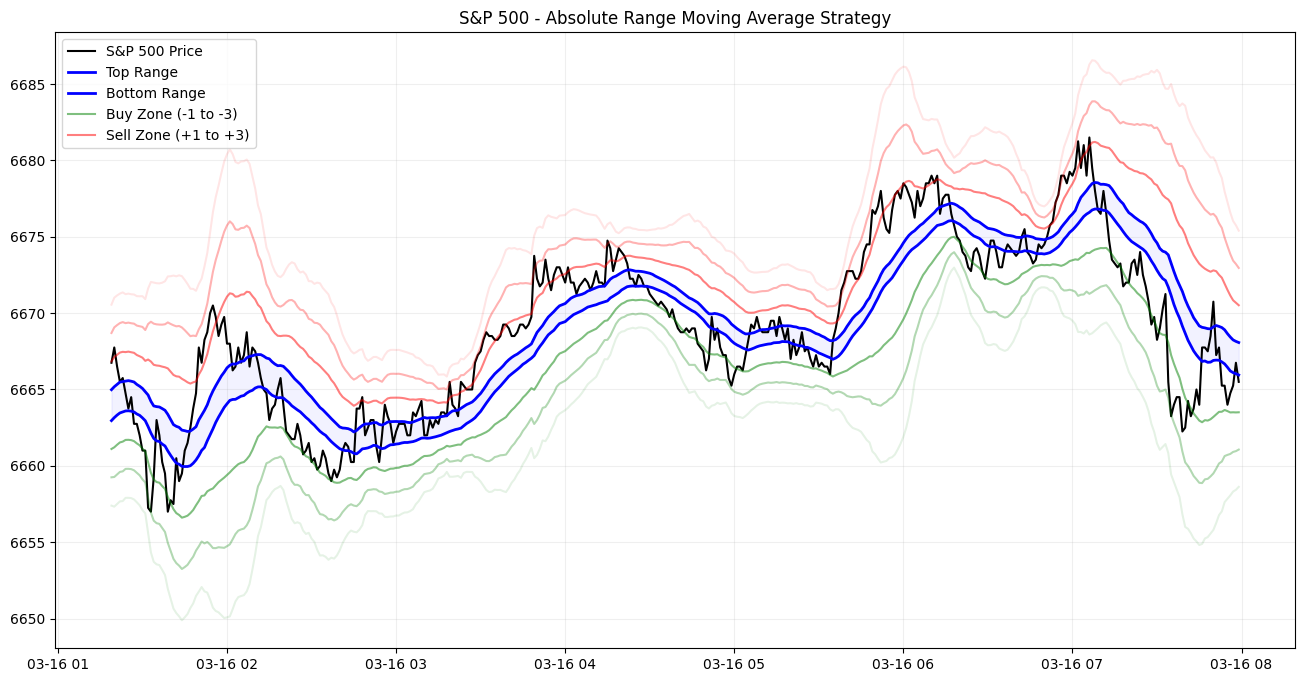

In [29]:
# Plot the last 400 minutes again to keep it readable
plot_df = df.iloc[-400:]

plt.figure(figsize=(16, 8))

# Actual Price
plt.plot(plot_df.index, plot_df['Close'], label='S&P 500 Price', color='black', linewidth=1.5)

# The "No Trade Zone" Range
plt.plot(plot_df.index, plot_df['Top_Range'], color='blue', linewidth=2, label='Top Range')
plt.plot(plot_df.index, plot_df['Bottom_Range'], color='blue', linewidth=2, label='Bottom Range')
plt.fill_between(plot_df.index, plot_df['Top_Range'], plot_df['Bottom_Range'], color='blue', alpha=0.05)

# Buying Zones (Under the Bottom Range)
plt.plot(plot_df.index, plot_df['Lower_1'], color='green', alpha=0.5, label='Buy Zone (-1 to -3)')
plt.plot(plot_df.index, plot_df['Lower_2'], color='green', alpha=0.3)
plt.plot(plot_df.index, plot_df['Lower_3'], color='green', alpha=0.1)

# Selling Zones (Above the Top Range)
plt.plot(plot_df.index, plot_df['Upper_1'], color='red', alpha=0.5, label='Sell Zone (+1 to +3)')
plt.plot(plot_df.index, plot_df['Upper_2'], color='red', alpha=0.3)
plt.plot(plot_df.index, plot_df['Upper_3'], color='red', alpha=0.1)

plt.title('S&P 500 - Absolute Range Moving Average Strategy')
plt.legend(loc='upper left')
plt.grid(True, alpha=0.2)
plt.show()

In [50]:
detailed_trades = []
long_inventory = []
short_inventory = []

# Our two optimization rules
bad_hours = [23, 2, 4, 6, 7]
min_width = 2.0

for i in range(len(df)):
    price = df['Close'].iloc[i].item()
    current_time = df.index[i]
    current_hour = current_time.hour

    top_range = df['Top_Range'].iloc[i]
    bot_range = df['Bottom_Range'].iloc[i]
    range_width = top_range - bot_range

    l1, l2, l3 = df['Lower_1'].iloc[i], df['Lower_2'].iloc[i], df['Lower_3'].iloc[i]
    stop_low = df['Stop_Low'].iloc[i]

    u1, u2, u3 = df['Upper_1'].iloc[i], df['Upper_2'].iloc[i], df['Upper_3'].iloc[i]
    stop_high = df['Stop_High'].iloc[i]

    # --- BUY LOGIC (LONG) ---
    if price <= stop_low and len(long_inventory) > 0:
        for entry_time, entry_price in long_inventory:
            detailed_trades.append({'Profit': (price - entry_price) / entry_price})
        long_inventory = []

    elif price >= bot_range and len(long_inventory) > 0:
        for entry_time, entry_price in long_inventory:
            detailed_trades.append({'Profit': (price - entry_price) / entry_price})
        long_inventory = []

    # NEW RULE: Check the hour AND the width of the pipe
    elif current_hour not in bad_hours and range_width >= min_width:
        if price <= l3 and len(long_inventory) == 2:
            long_inventory.append((current_time, price))
        elif price <= l2 and len(long_inventory) == 1:
            long_inventory.append((current_time, price))
        elif price <= l1 and len(long_inventory) == 0:
            long_inventory.append((current_time, price))

    # --- SELL LOGIC (SHORT) ---
    if price >= stop_high and len(short_inventory) > 0:
        for entry_time, entry_price in short_inventory:
            detailed_trades.append({'Profit': (entry_price - price) / entry_price})
        short_inventory = []

    elif price <= top_range and len(short_inventory) > 0:
        for entry_time, entry_price in short_inventory:
            detailed_trades.append({'Profit': (entry_price - price) / entry_price})
        short_inventory = []

    # NEW RULE: Check the hour AND the width of the pipe
    elif current_hour not in bad_hours and range_width >= min_width:
        if price >= u3 and len(short_inventory) == 2:
            short_inventory.append((current_time, price))
        elif price >= u2 and len(short_inventory) == 1:
            short_inventory.append((current_time, price))
        elif price >= u1 and len(short_inventory) == 0:
            short_inventory.append((current_time, price))

# Show the final optimized results
if len(detailed_trades) > 0:
    trade_log = pd.DataFrame(detailed_trades)
    wins = trade_log[trade_log['Profit'] > 0]
    accuracy = (len(wins) / len(trade_log)) * 100

    total_return = 1.0
    for p in trade_log['Profit']:
        total_return *= (1 + p)
    total_profit_pct = (total_return - 1) * 100

    print("--- FINAL OPTIMIZED STRATEGY ---")
    print(f"Total Trades Taken: {len(trade_log)}")
    print(f"Accuracy: {accuracy:.1f}%")
    print(f"Total Profit: {total_profit_pct:.3f}%")
else:
    print("No trades happened.")

--- FINAL OPTIMIZED STRATEGY ---
Total Trades Taken: 46046
Accuracy: 67.6%
Total Profit: 23346.708%


# **Now we try the algorithm on 13 years of SPY data.**

In [38]:
# Loading 13 years of data
df = pd.read_csv("spy_1min_2008_2021_cleaned.csv")

# 1. Convert the 'date' text into real computer time and make it the Index
df['date'] = pd.to_datetime(df['date'])
df.set_index('date', inplace=True)

# 2. Rename the columns to match our math block (capital letters)
df.rename(columns={'high': 'High', 'low': 'Low', 'close': 'Close'}, inplace=True)

# 3. Keep only the columns we actually need so we don't crash Colab's memory
df = df[['High', 'Low', 'Close']].copy()

print("Total minutes loaded:", len(df))

Loading 13 years of data...
Data reformatted and ready! Total minutes loaded: 2070834


In [55]:
detailed_trades = []
long_inventory = []
short_inventory = []

bad_hours = [23, 2, 4, 6, 7]
# NEW: We now use 0.1% of the price instead of a fixed number
min_width_pct = 0.001

total_rows = len(df)
closes = df['Close'].values
top_ranges = df['Top_Range'].values
bot_ranges = df['Bottom_Range'].values
l1s, l2s, l3s, stop_lows = df['Lower_1'].values, df['Lower_2'].values, df['Lower_3'].values, df['Stop_Low'].values
u1s, u2s, u3s, stop_highs = df['Upper_1'].values, df['Upper_2'].values, df['Upper_3'].values, df['Stop_High'].values
times = df.index

for i in range(total_rows):
    if i > 0 and i % 100000 == 0:
        print(f"Processed {i} out of {total_rows} minutes...")

    price = closes[i]
    current_time = times[i]
    current_hour = current_time.hour

    top_range = top_ranges[i]
    bot_range = bot_ranges[i]
    range_width = top_range - bot_range

    l1, l2, l3, stop_low = l1s[i], l2s[i], l3s[i], stop_lows[i]
    u1, u2, u3, stop_high = u1s[i], u2s[i], u3s[i], stop_highs[i]

    # NEW RULE: Check if the width is greater than 0.1% of the current price
    dynamic_min_width = price * min_width_pct

    # --- BUY LOGIC (LONG) ---
    if price <= stop_low and len(long_inventory) > 0:
        for entry_time, entry_price in long_inventory:
            detailed_trades.append({'Entry_Time': entry_time, 'Profit': (price - entry_price) / entry_price})
        long_inventory = []

    elif price >= bot_range and len(long_inventory) > 0:
        for entry_time, entry_price in long_inventory:
            detailed_trades.append({'Entry_Time': entry_time, 'Profit': (price - entry_price) / entry_price})
        long_inventory = []

    elif current_hour not in bad_hours and range_width >= dynamic_min_width:
        if price <= l3 and len(long_inventory) == 2:
            long_inventory.append((current_time, price))
        elif price <= l2 and len(long_inventory) == 1:
            long_inventory.append((current_time, price))
        elif price <= l1 and len(long_inventory) == 0:
            long_inventory.append((current_time, price))

    # --- SELL LOGIC (SHORT) ---
    if price >= stop_high and len(short_inventory) > 0:
        for entry_time, entry_price in short_inventory:
            detailed_trades.append({'Entry_Time': entry_time, 'Profit': (entry_price - price) / entry_price})
        short_inventory = []

    elif price <= top_range and len(short_inventory) > 0:
        for entry_time, entry_price in short_inventory:
            detailed_trades.append({'Entry_Time': entry_time, 'Profit': (entry_price - price) / entry_price})
        short_inventory = []

    elif current_hour not in bad_hours and range_width >= dynamic_min_width:
        if price >= u3 and len(short_inventory) == 2:
            short_inventory.append((current_time, price))
        elif price >= u2 and len(short_inventory) == 1:
            short_inventory.append((current_time, price))
        elif price >= u1 and len(short_inventory) == 0:
            short_inventory.append((current_time, price))

# Show the real 13-year results
if len(detailed_trades) > 0:
    trade_log = pd.DataFrame(detailed_trades)
    wins = trade_log[trade_log['Profit'] > 0]
    accuracy = (len(wins) / len(trade_log)) * 100

    total_return = 1.0
    for p in trade_log['Profit']:
        total_return *= (1 + p)
    total_profit_pct = (total_return - 1) * 100

    print("--- 13-YEAR DYNAMIC BACKTEST COMPLETE ---")
    print(f"Total Trades Taken: {len(trade_log)}")
    print(f"Real Accuracy: {accuracy:.1f}%")
    print(f"Real Compounded Profit: {total_profit_pct:.2f}%")
else:
    print("No trades happened.")

Processed 100000 out of 2070776 minutes...
Processed 200000 out of 2070776 minutes...
Processed 300000 out of 2070776 minutes...
Processed 400000 out of 2070776 minutes...
Processed 500000 out of 2070776 minutes...
Processed 600000 out of 2070776 minutes...
Processed 700000 out of 2070776 minutes...
Processed 800000 out of 2070776 minutes...
Processed 900000 out of 2070776 minutes...
Processed 1000000 out of 2070776 minutes...
Processed 1100000 out of 2070776 minutes...
Processed 1200000 out of 2070776 minutes...
Processed 1300000 out of 2070776 minutes...
Processed 1400000 out of 2070776 minutes...
Processed 1500000 out of 2070776 minutes...
Processed 1600000 out of 2070776 minutes...
Processed 1700000 out of 2070776 minutes...
Processed 1800000 out of 2070776 minutes...
Processed 1900000 out of 2070776 minutes...
Processed 2000000 out of 2070776 minutes...
--- 13-YEAR DYNAMIC BACKTEST COMPLETE ---
Total Trades Taken: 10237
Real Accuracy: 68.0%
Real Compounded Profit: 3561.53%


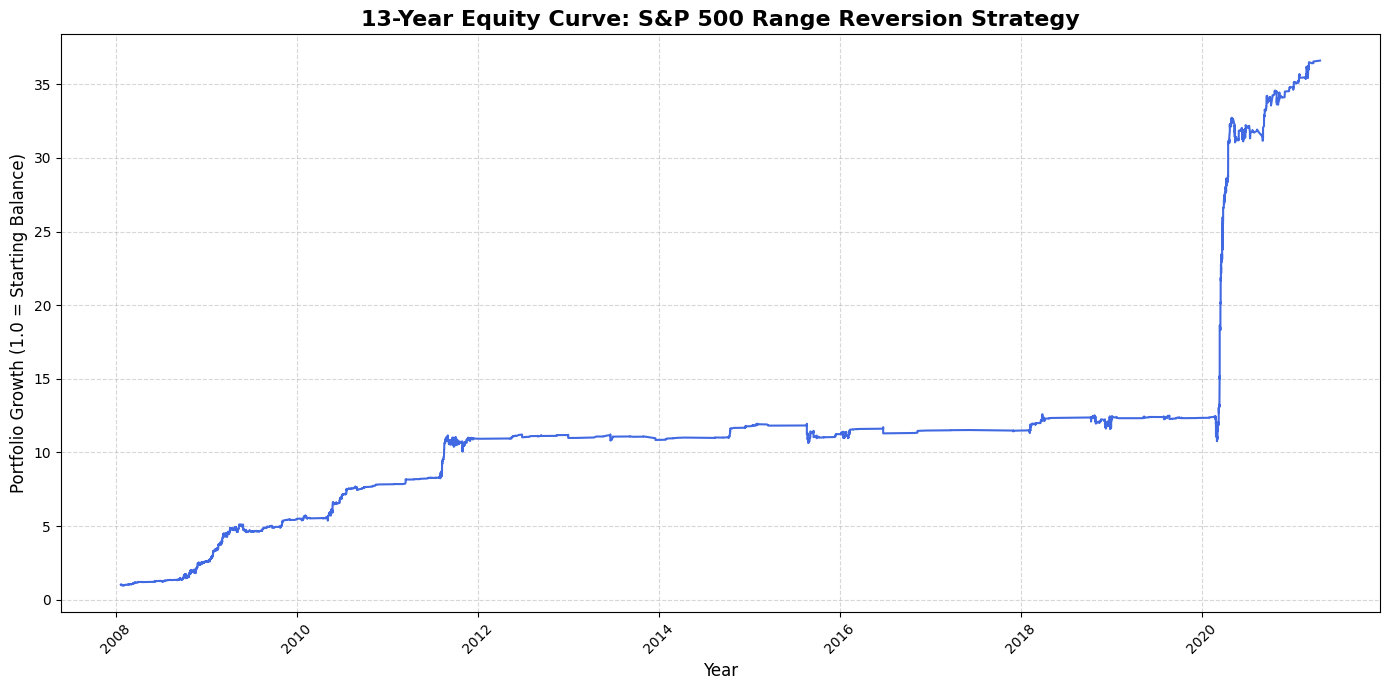

In [56]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Make sure we are using our 13-year trade log
trade_log = pd.DataFrame(detailed_trades)

# Calculate the compound growth line
# We add 1 to the profit (so a 2% win becomes 1.02), then multiply them all together in order
trade_log['Cumulative_Return'] = (1 + trade_log['Profit']).cumprod()

# Set up a nice, wide chart
plt.figure(figsize=(14, 7))

# Draw the actual equity curve line
plt.plot(trade_log['Entry_Time'], trade_log['Cumulative_Return'], color='royalblue', linewidth=1.5)

# Add titles and labels to make it look professional
plt.title('13-Year Equity Curve: S&P 500 Range Reversion Strategy', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Portfolio Growth (1.0 = Starting Balance)', fontsize=12)

# Make the background grid look clean
plt.grid(True, linestyle='--', alpha=0.5)

# Format the dates on the bottom so they are easy to read
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)

# Show the final chart
plt.tight_layout()
plt.show()

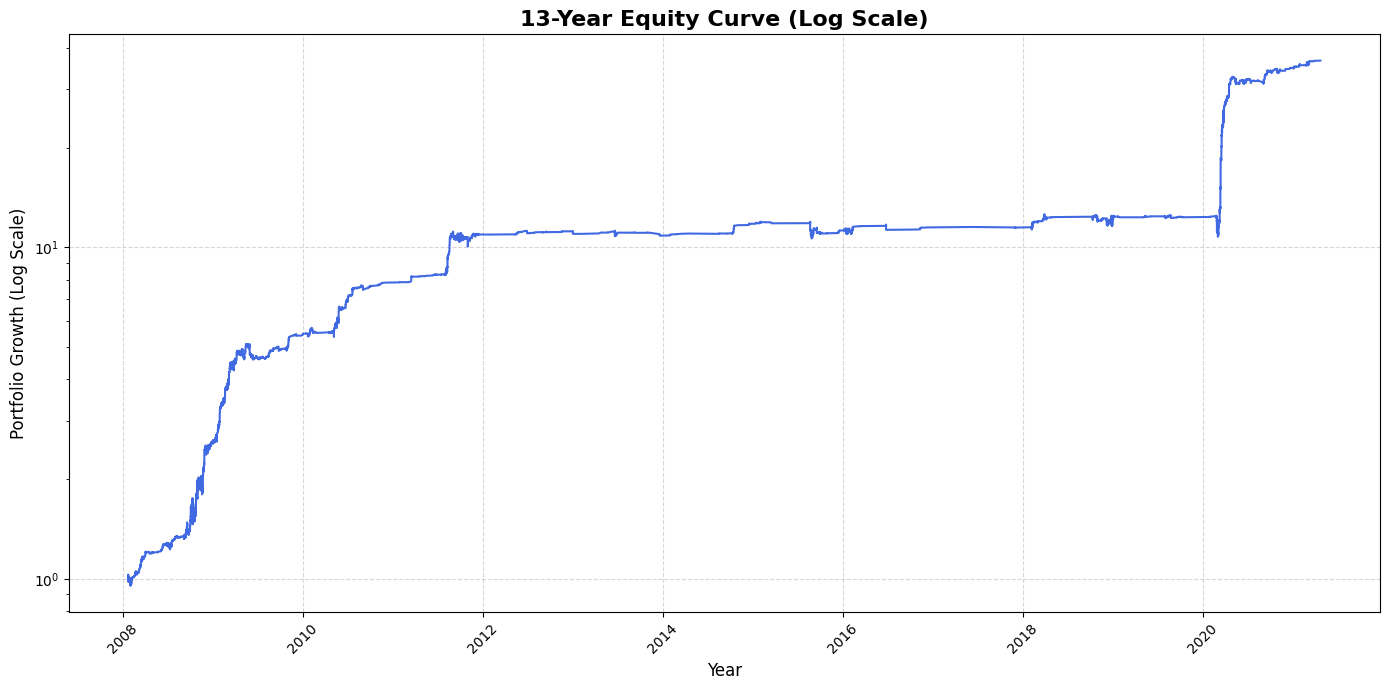

In [57]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

# Make sure we are using our updated 10,000 trade log
trade_log = pd.DataFrame(detailed_trades)
trade_log['Cumulative_Return'] = (1 + trade_log['Profit']).cumprod()

plt.figure(figsize=(14, 7))
plt.plot(trade_log['Entry_Time'], trade_log['Cumulative_Return'], color='royalblue', linewidth=1.5)

# --- THE FIX ---
# This forces the chart to show percentage growth, not absolute numbers
plt.yscale('log')

plt.title('13-Year Equity Curve (Log Scale)', fontsize=16, fontweight='bold')
plt.xlabel('Year', fontsize=12)
plt.ylabel('Portfolio Growth (Log Scale)', fontsize=12)

plt.grid(True, linestyle='--', alpha=0.5)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [58]:
# Get the very first price in our 13-year dataset
start_price = df['Close'].iloc[0]

# Get the very last price in our dataset
end_price = df['Close'].iloc[-1]

# Calculate the percentage growth
buy_and_hold_return = ((end_price - start_price) / start_price) * 100

print("--- PERFORMANCE COMPARISON ---")
print(f"Algorithm Compounded Return: {total_profit_pct:.2f}%")
print(f"S&P 500 Buy & Hold Return: {buy_and_hold_return:.2f}%")

# Let's also print out your Max Drawdown from the previous step just to have it all together
print(f"Algorithm Maximum Drawdown: {max_drawdown:.2f}%")

--- PERFORMANCE COMPARISON ---
Algorithm Compounded Return: 3561.53%
S&P 500 Buy & Hold Return: 220.77%
Algorithm Maximum Drawdown: -16.55%
